In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns

C:\Users\DINESHWAR\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
file_path = r"F:\intern data sets\un supervised learning data\Forecasting data\Boys.xlsb"
file_path2 =r"F:\intern data sets\un supervised learning data\Additional data\boys data - additional months.xlsb"

In [3]:
boy_sales = pd.read_excel(file_path, sheet_name='Sale')
boy_sales_2 = pd.read_excel(file_path2, sheet_name = 'Sale')

In [4]:
print(boy_sales.shape)
print(boy_sales_2.shape)

(77643, 51)
(11794, 51)


In [5]:
df_sal = pd.concat([boy_sales, boy_sales_2], ignore_index=True)

In [6]:
zero_ratio = (df_sal['Qty'] == 0).mean()
print('Zero Percentage:', zero_ratio * 100)

Zero Percentage: 0.0


In [7]:
df_sal['Qty'].value_counts(normalize=True)

Qty
 1    0.972539
-1    0.022709
 2    0.004506
 3    0.000123
-2    0.000078
 4    0.000045
Name: proportion, dtype: float64

In [8]:
target_depts = ['KNIT TOP SETS', 'WOVEN TOP SETS']
df = df_sal[df_sal['Department'].isin(target_depts)].copy()
print("After dept filter:", df.shape)

After dept filter: (46038, 51)


In [9]:
df.head(3)

,Document Type,Month,Posting Date,Warehouse Name,Warehouse Code,Group Name,Division,Section,Department,Sku Code,...,Fabric Desc,Fabric Pattern,Length,Product Type,Division Group,Brand Type,Corrected Data,Qty,COST/PCS,Net Sale Value
0,Sales,OCTOBER,45937,TRICHY,TR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND9MRGNFDPRSSSHRNNC,...,NaN,PRINTS,SHORT,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$0/M/14$...,1,190.90,360.00
1,Sales,OCTOBER,45937,AMBATTUR,AR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1TRGNFDPRSSSHRNNC,...,NaN,PRINTS,SHORT,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$2/XL/18...,1,186.75,355.01
2,Sales,OCTOBER,45937,TRICHY,TR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND2YRGNFDSTSSSHNNRC,...,NaN,STRIPE,SHORT,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$3/2XL/2...,1,419.40,699.00


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 46038 entries, 0 to 89434
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Document Type        46038 non-null  str    
 1   Month                46038 non-null  str    
 2   Posting Date         46038 non-null  int64  
 3   Warehouse Name       46038 non-null  str    
 4   Warehouse Code       46038 non-null  str    
 5   Group Name           46038 non-null  str    
 6   Division             46038 non-null  str    
 7   Section              46038 non-null  str    
 8   Department           46038 non-null  str    
 9   Sku Code             46038 non-null  str    
 10  Batch Number         46038 non-null  str    
 11  Batch System Number  46038 non-null  int64  
 12  Batch Abs Entry      46038 non-null  int64  
 13  Brand                46023 non-null  str    
 14  Style                46023 non-null  object 
 15  Shade                44186 non-null  str    
 16  Si

In [11]:
df.columns

Index(['Document Type', 'Month', 'Posting Date', 'Warehouse Name',
       'Warehouse Code', 'Group Name', 'Division', 'Section', 'Department',
       'Sku Code', 'Batch Number', 'Batch System Number', 'Batch Abs Entry',
       'Brand', 'Style', 'Shade', 'Size', 'Fit', 'Material', 'Mrp', 'Range',
       'Vendor code', 'Vendor Name', 'Batch Created Date',
       'Aging on Sale date', 'No Of Packs', 'Season', 'Agency', 'Top/Bottom',
       'Article Description', 'Category Desc', 'Mp', 'Vendor Color',
       'Vnh Color', 'Neck', 'Collar', 'Placket', 'Sleeve', 'Pocket', 'Fabrics',
       'Fabric Type', 'Fabric Desc', 'Fabric Pattern', 'Length',
       'Product Type', 'Division Group', 'Brand Type', 'Corrected Data', 'Qty',
       'COST/PCS', 'Net Sale Value'],
      dtype='str')

In [12]:
print(dict(df.dtypes))

{'Document Type': <StringDtype(na_value=nan)>, 'Month': <StringDtype(na_value=nan)>, 'Posting Date': dtype('int64'), 'Warehouse Name': <StringDtype(na_value=nan)>, 'Warehouse Code': <StringDtype(na_value=nan)>, 'Group Name': <StringDtype(na_value=nan)>, 'Division': <StringDtype(na_value=nan)>, 'Section': <StringDtype(na_value=nan)>, 'Department': <StringDtype(na_value=nan)>, 'Sku Code': <StringDtype(na_value=nan)>, 'Batch Number': <StringDtype(na_value=nan)>, 'Batch System Number': dtype('int64'), 'Batch Abs Entry': dtype('int64'), 'Brand': <StringDtype(na_value=nan)>, 'Style': dtype('O'), 'Shade': <StringDtype(na_value=nan)>, 'Size': <StringDtype(na_value=nan)>, 'Fit': <StringDtype(na_value=nan)>, 'Material': <StringDtype(na_value=nan)>, 'Mrp': dtype('float64'), 'Range': <StringDtype(na_value=nan)>, 'Vendor code': <StringDtype(na_value=nan)>, 'Vendor Name': <StringDtype(na_value=nan)>, 'Batch Created Date': dtype('int64'), 'Aging on Sale date': dtype('float64'), 'No Of Packs': dtype('

In [13]:
df.columns = df_sal.columns.str.strip().str.lower().str.replace(' ', '_')


In [14]:
df['posting_date'] = pd.to_datetime(df['posting_date'],unit='D', origin='1899-12-30')
df['batch_created_date'] = pd.to_datetime(df['batch_created_date'],unit='D', origin='1899-12-30')

In [15]:
df['posting_date'].isnull().sum()

np.int64(0)

In [16]:


df['batch_created_date'].isnull().sum()

np.int64(0)

In [17]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
print(dict(null_counts))

{'no_of_packs': np.int64(46038), 'agency': np.int64(46038), 'top/bottom': np.int64(46038), 'fabric_desc': np.int64(46038), 'placket': np.int64(45571), 'category_desc': np.int64(44782), 'pocket': np.int64(37997), 'mp': np.int64(35838), 'collar': np.int64(30473), 'article_description': np.int64(24631), 'neck': np.int64(21245), 'vnh_color': np.int64(9954), 'vendor_color': np.int64(8981), 'fabrics': np.int64(8792), 'fabric_type': np.int64(6793), 'fabric_pattern': np.int64(6127), 'material': np.int64(1920), 'shade': np.int64(1852), 'season': np.int64(1008), 'fit': np.int64(505), 'range': np.int64(21), 'brand': np.int64(15), 'vendor_code': np.int64(15), 'vendor_name': np.int64(15), 'style': np.int64(15), 'aging_on_sale_date': np.int64(6)}


EDA PERFORMING


In [18]:
df.isnull().sum()

document_type              0
month                      0
posting_date               0
warehouse_name             0
warehouse_code             0
group_name                 0
division                   0
section                    0
department                 0
sku_code                   0
batch_number               0
batch_system_number        0
batch_abs_entry            0
brand                     15
style                     15
shade                   1852
size                       0
fit                      505
material                1920
mrp                        0
range                     21
vendor_code               15
vendor_name               15
batch_created_date         0
aging_on_sale_date         6
no_of_packs            46038
season                  1008
agency                 46038
top/bottom             46038
article_description    24631
category_desc          44782
mp                     35838
vendor_color            8981
vnh_color               9954
neck          

In [19]:
print("\nUnique Departments:")
print(df['department'].value_counts())

print("\nUnique Sleeve:")
print(df['sleeve'].value_counts())

print("\nUnique Length:")
print(df['length'].value_counts())

print("\nUnique Range:")
print(df['range'].value_counts())


Unique Departments:
department
KNIT TOP SETS     30578
WOVEN TOP SETS    15460
Name: count, dtype: int64

Unique Sleeve:
sleeve
SHORT SLEEVE    32831
FULL SLEEVE      9824
SLEEVE LESS      3181
CAP SLEEVE        108
Full Sleeve        58
Short Sleeve       36
Name: count, dtype: int64

Unique Length:
length
SHORT                  28850
FULL LENGTH             9947
REGULAR                 6860
ABOVE KNEE (1/2)         170
CALF LENGTH (3/4TH)       77
Full Length               58
Regular                   36
MINI                      22
KNEE LENGTH               10
CROP                       8
Name: count, dtype: int64

Unique Range:
range
401-700      14395
200-400      10254
701-1050      9726
1201-1650     3507
600-1200      3267
1651-2200     1846
1051-2500     1651
2201-3400     1371
Name: count, dtype: int64


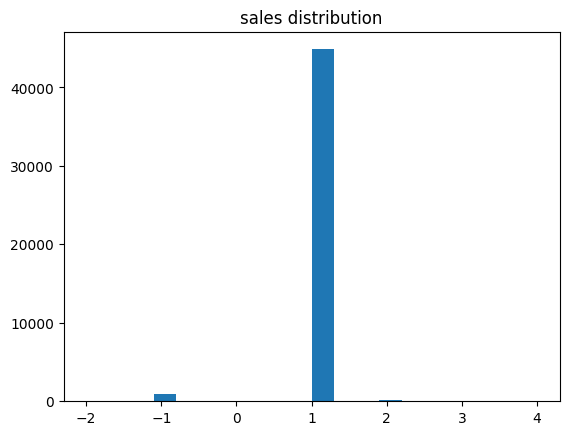

In [20]:
import matplotlib.pyplot as plt

plt.hist(df['qty'],bins=20)
plt.title('sales distribution')
plt.show()


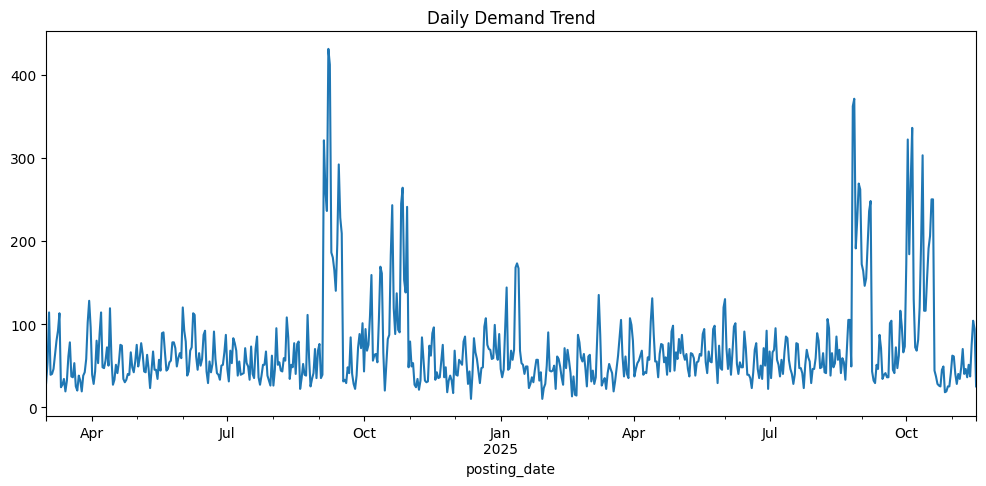

In [21]:
daily_sales = df.groupby('posting_date')['qty'].sum()

daily_sales.plot(figsize=(12,5))
plt.title("Daily Demand Trend")
plt.show()

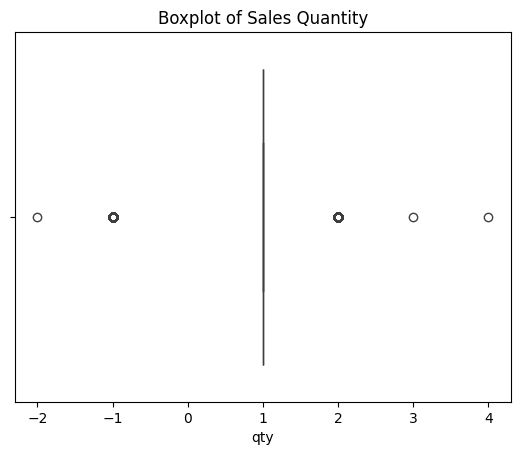

In [22]:
sns.boxplot(x=df['qty'])
plt.title('Boxplot of Sales Quantity')
plt.show()

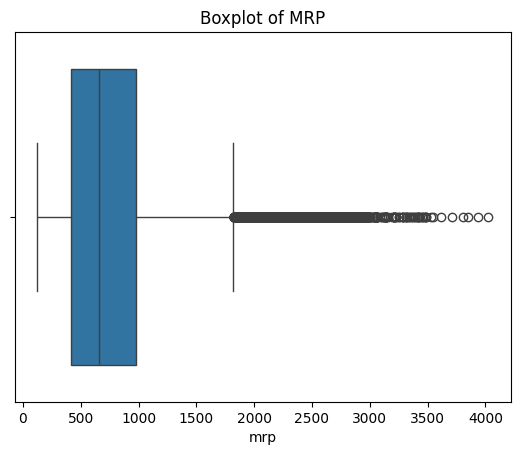

In [23]:
sns.boxplot(x=df['mrp'])
plt.title('Boxplot of MRP')
plt.show()

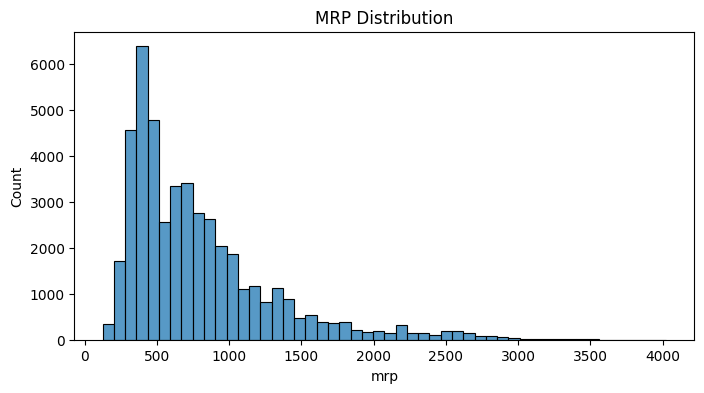

In [24]:
plt.figure(figsize=(8,4))
sns.histplot(df['mrp'], bins=50)
plt.title("MRP Distribution")
plt.show()

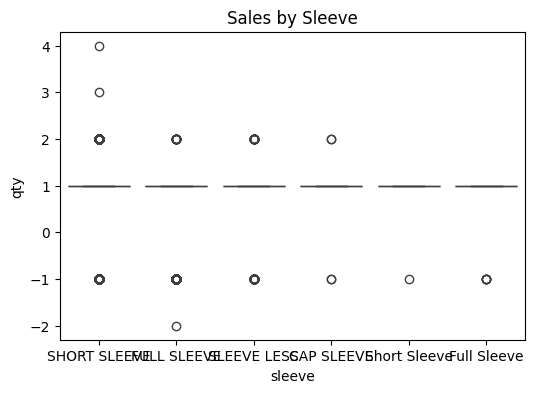

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sleeve', y='qty', data=df)
plt.title("Sales by Sleeve")
plt.show()

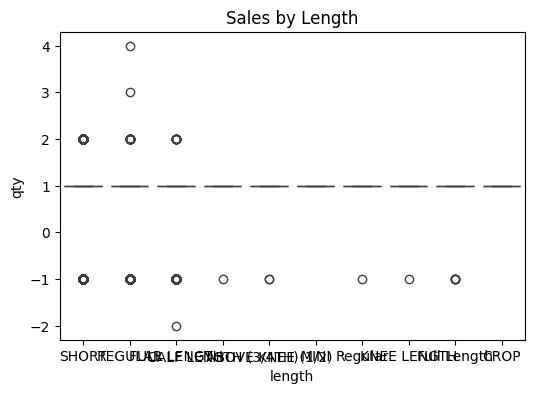

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='length', y='qty', data=df)
plt.title("Sales by Length")
plt.show()


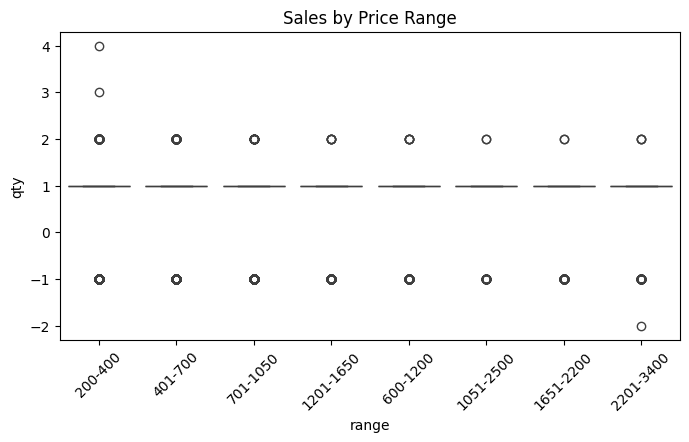

In [27]:
plt.figure(figsize=(8,4))
sns.boxplot(x='range', y='qty', data=df)
plt.xticks(rotation=45)
plt.title("Sales by Price Range")
plt.show()


In [28]:
print("\nMin value:", df['posting_date'].min())
print("Max value:", df['posting_date'].max())


Min value: 2024-03-01 00:00:00
Max value: 2025-11-17 00:00:00


In [29]:
print("Min:", df['batch_created_date'].min(), " Max:", df['batch_created_date'].max())

Min: 2015-09-01 00:00:00  Max: 2025-10-29 00:00:00


In [30]:
df['department'].value_counts()

department
KNIT TOP SETS     30578
WOVEN TOP SETS    15460
Name: count, dtype: int64

In [31]:

df['sleeve'] = df['sleeve'].str.strip().str.upper()

In [32]:
df['sleeve'] = df['sleeve'].apply(lambda x: 'Full Sleeve' if x == 'FULL SLEEVE' else 'Sleeve Less' if x == 'SLEEVE LESS' else 'Short Sleeve')

In [33]:
print(df['sleeve'].value_counts())
print(df['sleeve'].isnull().sum())

sleeve
Short Sleeve    32975
Full Sleeve      9882
Sleeve Less      3181
Name: count, dtype: int64
0


Data Cleaning And Standardizing


In [34]:
df['length'] = df['length'].str.strip().str.upper()

In [35]:
df['length'] = df['length'].apply(lambda x: 'FULL LENGTH' if x == 'FULL LENGTH' else 'HALF LENGTH')

In [36]:
df_clean = df.copy()

In [37]:
df_clean['sleeve'].value_counts()

sleeve
Short Sleeve    32975
Full Sleeve      9882
Sleeve Less      3181
Name: count, dtype: int64

In [38]:
df_na = df[['department','posting_date',
         'size',
         'mrp',
         'range','warehouse_code',
         'batch_created_date',
         'aging_on_sale_date',
         'sleeve',
         'length',
         'qty',
         'net_sale_value']]

In [39]:
df_na.isnull().sum()

department             0
posting_date           0
size                   0
mrp                    0
range                 21
warehouse_code         0
batch_created_date     0
aging_on_sale_date     6
sleeve                 0
length                 0
qty                    0
net_sale_value         0
dtype: int64

In [40]:
group_cols = [
    "posting_date",
    "department",
    "sleeve",
    "length",
    "range",
    "size",
    "warehouse_code"
]

df.duplicated(subset=group_cols).sum()

np.int64(11098)

In [41]:
bins = [0,200,400,700,1050,1650,2200,3400,4500]

labels = [
'0-200',
'200-400',
'401-700',
'701-1050',
'1051-1650',
'1651-2200',
'2201-3400',
'3401-4500'
]

df['range'] = pd.cut(df['mrp'], bins=bins, labels=labels)

In [42]:
df['range'].value_counts().sort_index()

range
0-200          335
200-400      10374
401-700      14610
701-1050     10992
1051-1650     6504
1651-2200     1815
2201-3400     1387
3401-4500       21
Name: count, dtype: int64

In [43]:
df_clean['mrp'].isna().sum()

np.int64(0)

In [44]:
df['range'].isnull().sum()

np.int64(0)

In [45]:
df.columns

Index(['document_type', 'month', 'posting_date', 'warehouse_name',
       'warehouse_code', 'group_name', 'division', 'section', 'department',
       'sku_code', 'batch_number', 'batch_system_number', 'batch_abs_entry',
       'brand', 'style', 'shade', 'size', 'fit', 'material', 'mrp', 'range',
       'vendor_code', 'vendor_name', 'batch_created_date',
       'aging_on_sale_date', 'no_of_packs', 'season', 'agency', 'top/bottom',
       'article_description', 'category_desc', 'mp', 'vendor_color',
       'vnh_color', 'neck', 'collar', 'placket', 'sleeve', 'pocket', 'fabrics',
       'fabric_type', 'fabric_desc', 'fabric_pattern', 'length',
       'product_type', 'division_group', 'brand_type', 'corrected_data', 'qty',
       'cost/pcs', 'net_sale_value'],
      dtype='str')

In [46]:
df_clean = df.copy()

In [47]:
df_clean

,document_type,month,posting_date,warehouse_name,warehouse_code,group_name,division,section,department,sku_code,...,fabric_desc,fabric_pattern,length,product_type,division_group,brand_type,corrected_data,qty,cost/pcs,net_sale_value
0,Sales,OCTOBER,2025-10-07,TRICHY,TR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND9MRGNFDPRSSSHRNNC,...,NaN,PRINTS,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$0/M/14$...,1,190.90,360.00
1,Sales,OCTOBER,2025-10-07,AMBATTUR,AR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1TRGNFDPRSSSHRNNC,...,NaN,PRINTS,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$2/XL/18...,1,186.75,355.01
2,Sales,OCTOBER,2025-10-07,TRICHY,TR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND2YRGNFDSTSSSHNNRC,...,NaN,STRIPE,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$3/2XL/2...,1,419.40,699.00
3,Sales,OCTOBER,2025-10-07,SALEM16,SB,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND9MRGNFDEMSSSHNNHO,...,NaN,EMBROIDERY,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$0/M/14$...,1,297.30,569.00
4,Sales,OCTOBER,2025-10-07,VELACHERY,VC,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1TRGNFDEMSSSHNNHO,...,NaN,EMBROIDERY,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$2/XL/18...,1,297.30,569.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89430,Sales,NOVEMBER,2025-11-17,VALSARAVAKKAM,VA,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1YRGNFDSTSSSHRNNC,...,NaN,STRIPE,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$1/L/16$...,1,375.72,775.01
89431,Sales,NOVEMBER,2025-11-17,VALSARAVAKKAM,VA,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1TRGNFDPRSSSHRNNC,...,NaN,PRINTS,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$2/XL/18...,1,182.60,355.01
89432,Sales,NOVEMBER,2025-11-17,VALSARAVAKKAM,VA,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1TRGNFDPRSSSHRNNC,...,NaN,PRINTS,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$2/XL/18...,1,225.00,450.00
89433,Sales,NOVEMBER,2025-11-17,VALSARAVAKKAM,VA,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND3YRGNFDPRSSSHRNNC,...,NaN,PRINTS,HALF LENGTH,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$4/3XL/2...,1,228.25,445.00


In [48]:
df_clean = df_clean[(df_clean['qty'] > 0) & (df_clean['net_sale_value'] > 0)]

In [49]:
print("Remaining shape:", df_clean.shape)

print("Negative Qty remaining:", (df_clean['qty'] < 0).sum())
print("Negative Net Sales remaining:", (df_clean['net_sale_value'] < 0).sum())

Remaining shape: (45044, 51)
Negative Qty remaining: 0
Negative Net Sales remaining: 0


In [50]:
df_clean = df_clean.reset_index(drop=True)

In [51]:
df_clean["selling_price"] = df_clean["net_sale_value"] / df_clean["qty"]

df_clean["discount_value"] = df_clean["mrp"] - df_clean["selling_price"]

df_clean["discount_pct"] = df_clean["discount_value"] / df_clean["mrp"]

df_clean["price_gap"] = df_clean["discount_value"]

In [52]:
print(df_clean[['mrp','selling_price','discount_pct','price_gap']].head())

     mrp  selling_price  discount_pct  price_gap
0  360.0         360.00      0.000000       0.00
1  355.0         355.01     -0.000028      -0.01
2  699.0         699.00      0.000000       0.00
3  569.0         569.00      0.000000       0.00
4  569.0         569.00      0.000000       0.00


In [53]:
df_clean['discount_pct'] = df_clean['discount_pct'].clip(lower=0)

In [54]:
print(df_clean['discount_pct'].describe())

count    45044.000000
mean         0.052146
std          0.119278
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.917431
Name: discount_pct, dtype: float64


In [55]:
df_clean = df_clean[['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'batch_created_date', 'aging_on_sale_date', 'sleeve', 'length', 'qty',
       'net_sale_value', 'selling_price', 'discount_value', 'discount_pct',
       'price_gap']]

In [56]:
df_clean['month'] = df_clean['posting_date'].dt.month
df_clean['week'] = df_clean['posting_date'].dt.isocalendar().week
df_clean['day_of_week'] = df_clean['posting_date'].dt.dayofweek
df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)

In [57]:
df_clean['product_age'] = (
    df_clean['posting_date'] - df_clean['batch_created_date']
).dt.days

In [58]:
df_clean['week_start_date'] = df_clean['posting_date'] - pd.to_timedelta(
    df_clean['posting_date'].dt.weekday, unit='D'
)

In [59]:
df_clean['product_age_week'] = df_clean['product_age'] // 7

In [60]:
df_clean.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'batch_created_date', 'aging_on_sale_date', 'sleeve', 'length', 'qty',
       'net_sale_value', 'selling_price', 'discount_value', 'discount_pct',
       'price_gap', 'month', 'week', 'day_of_week', 'is_weekend',
       'product_age', 'week_start_date', 'product_age_week'],
      dtype='str')

In [61]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
)

In [62]:
try:
    import xgboost as xgb
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

In [63]:
def build_grouped_dataset(df):
    df = df.copy()
    df = df.reset_index(drop=True)

    group_keys = [
        "week_start_date",
        "department",
        "sleeve",
        "length",
        "range",
        "size",
        "warehouse_code"
    ]

    agg_dict = {
        "qty": "sum",
        "net_sale_value": "sum",
        "mrp": "mean",
        "product_age_week": "mean",
        "month": "first",
        "week": "first",
        "day_of_week": "mean",
        "is_weekend": "mean"
    }

    df_agg = (
        df.groupby(group_keys)
        .agg(agg_dict)
        .reset_index()
    )
    df_agg.rename(columns={"qty": "weekly_qty"}, inplace=True)
    df_agg = df_agg.sort_values(
        ["department","sleeve","length","range","size","week_start_date"]
    )

    print("Grouped dataset shape:", df_agg.shape)

    return df_agg

In [64]:
def engineer_features(df):

    df = df.copy()

    df["selling_price"] = (
        df["net_sale_value"] / df["weekly_qty"].replace(0, np.nan)
    ).fillna(df["mrp"])

    df["discount_pct"] = (
        (df["mrp"] - df["selling_price"]) /
        df["mrp"].replace(0, np.nan)
    ).fillna(0)

    df["price_bucket"] = pd.qcut(
        df["mrp"],
        q=5,
        labels=False,
        duplicates="drop"
    ).fillna(0)

    df["quarter"] = df["week_start_date"].dt.quarter
    df["year"] = df["week_start_date"].dt.year

    df["sku_key"] = (
        df["department"].astype(str) + "_" +
        df["sleeve"].astype(str) + "_" +
        df["length"].astype(str) + "_" +
        df["range"].astype(str) + "_" +
        df["size"].astype(str)
    )

    g = df.groupby("sku_key")["weekly_qty"]

    df["lag_1"] = g.shift(1)
    df["lag_2"] = g.shift(2)
    df["lag_4"] = g.shift(4)

    df["rolling_mean_2"] = g.shift(1).rolling(2).mean()
    df["rolling_mean_4"] = g.shift(1).rolling(4).mean()

    df["rolling_std_2"] = g.shift(1).rolling(2).std()

    df["momentum"] = df["lag_1"] - df["lag_2"]

    df["attributes_sales_mean"] = df.groupby(
        ["sleeve","length","range"]
    )["weekly_qty"].transform("mean")

    df["department_sales_mean"] = df.groupby(
        "department"
    )["weekly_qty"].transform("mean")

    df["warehouse_avg_sales"] = df.groupby(
        "warehouse_code"
    )["weekly_qty"].transform("mean")

    df["size_sales_mean"] = df.groupby(
        "size"
    )["weekly_qty"].transform("mean")

    from sklearn.preprocessing import LabelEncoder

    cat_cols = [
        "department",
        "sleeve",
        "length",
        "range",
        "size",
        "warehouse_code"
    ]

    for c in cat_cols:
        le = LabelEncoder()
        df[c+"_enc"] = le.fit_transform(df[c].astype(str))

    print("Feature dataset shape:", df.shape)

    return df

In [65]:
FEATURE_COLS = [

    "department_enc",
    "sleeve_enc",
    "length_enc",
    "range_enc",
    "size_enc",
    "warehouse_code_enc",

    "mrp",
    "discount_pct",
    "price_bucket",

    "month",
    "week",
    "quarter",

    "day_of_week",
    "is_weekend",

    "product_age_week",

    "attributes_sales_mean",
    "department_sales_mean",
    "warehouse_avg_sales",
    "size_sales_mean",

    "lag_1",
    "lag_2",
    "lag_4",

    "rolling_mean_2",
    "rolling_mean_4",
    "rolling_std_2",

    "momentum"
]

TARGET = "weekly_qty"

In [66]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

def train_and_evaluate(df, feature_cols):

    print("="*60, "STEP 5 : MODEL TRAINING & EVALUATION  (TimeSeriesSplit CV)", "="*60)

    df = df.copy()

    # Drop NA from lag/rolling
    df = df.dropna().reset_index(drop=True)

    X = df[feature_cols]
    y = df[TARGET]

    tscv = TimeSeriesSplit(n_splits=5)

    models = get_models()

    results = {}
    best_model_name = None
    best_mape = np.inf

    
    for name, model in models.items():

        mape_scores = []
        wape_scores = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            mape = mape_score(y_val.values, y_pred)
            wape_val = wape(y_val.values, y_pred)

            mape_scores.append(mape)
            wape_scores.append(wape_val)

        avg_mape = np.mean(mape_scores)
        avg_wape = np.mean(wape_scores)

        results[name] = {
            "MAPE": avg_mape,
            "WAPE": avg_wape
        }

        print(f"{name:<25} MAPE= {avg_mape:.2f}%   WAPE= {avg_wape:.2f}%")

        if avg_mape < best_mape:
            best_mape = avg_mape
            best_model_name = name

   
    print("\nBest model selected :", best_model_name)

    best_model = get_models()[best_model_name]

    
    best_model.fit(X, y)
    y_pred_full = best_model.predict(X)

    final_mape = mape_score(y.values, y_pred_full)
    final_wape = wape(y.values, y_pred_full)

    print("\nFINAL MODEL PERFORMANCE")
    print("-"*28)
    print(f"Final MAPE : {final_mape:.2f}%")
    print(f"Final WAPE : {final_wape:.2f}%")

    return {
        "model": best_model,
        "model_name": best_model_name,
        "metrics": results,
        "final_mape": final_mape,
        "final_wape": final_wape
    }

In [67]:
from sklearn.metrics import mean_absolute_percentage_error

def wape(y_true, y_pred):

    return (
        np.sum(np.abs(y_true - y_pred)) /
        np.sum(np.abs(y_true))
    ) * 100


def mape_score(y_true, y_pred):

    mask = y_true > 0

    return mean_absolute_percentage_error(
        y_true[mask],
        y_pred[mask]
    ) * 100

In [68]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

def get_models():

    return {

        "HistGradientBoosting":
        HistGradientBoostingRegressor(
            max_iter=400,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ),

        "GradientBoosting":
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5
        ),

        "RandomForest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            n_jobs=-1
        ),

        "ExtraTrees":
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=8,
            n_jobs=-1
        )
    }

In [69]:
df_grouped = build_grouped_dataset(df_clean)

Grouped dataset shape: (23883, 15)


In [70]:
df_features = engineer_features(df_grouped)

Feature dataset shape: (23883, 38)


In [71]:
pipeline_output = train_and_evaluate(df_features, FEATURE_COLS)

============================================================ STEP 5 : MODEL TRAINING & EVALUATION  (TimeSeriesSplit CV) ============================================================
HistGradientBoosting      MAPE= 24.29%   WAPE= 28.17%
GradientBoosting          MAPE= 23.58%   WAPE= 26.91%
RandomForest              MAPE= 30.43%   WAPE= 33.49%
ExtraTrees                MAPE= 34.06%   WAPE= 35.05%

Best model selected : GradientBoosting

FINAL MODEL PERFORMANCE
----------------------------
Final MAPE : 18.80%
Final WAPE : 20.47%


In [72]:
model = pipeline_output["model"]

In [73]:
importance = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

In [74]:
print(importance.head(15))

is_weekend               0.307545
discount_pct             0.178392
warehouse_avg_sales      0.144401
attributes_sales_mean    0.105962
rolling_mean_4           0.064891
day_of_week              0.057280
lag_1                    0.039194
product_age_week         0.025104
mrp                      0.023002
size_sales_mean          0.017964
rolling_mean_2           0.010905
week                     0.009178
lag_4                    0.003074
month                    0.002821
momentum                 0.002800
dtype: float64


In [75]:
importance_df = importance.reset_index()
importance_df.columns = ["Feature", "Importance"]

print(importance_df.head(15))

                  Feature  Importance
0              is_weekend    0.307545
1            discount_pct    0.178392
2     warehouse_avg_sales    0.144401
3   attributes_sales_mean    0.105962
4          rolling_mean_4    0.064891
5             day_of_week    0.057280
6                   lag_1    0.039194
7        product_age_week    0.025104
8                     mrp    0.023002
9         size_sales_mean    0.017964
10         rolling_mean_2    0.010905
11                   week    0.009178
12                  lag_4    0.003074
13                  month    0.002821
14               momentum    0.002800
